# Spain — Telecommunications | Exploration & QA

Phase 1, Deliverable 1 — Market Intelligence Database.

This notebook loads `operators.csv` + `sources.csv`, runs quality-assurance checks against CNMC sector aggregates, and produces summary visuals + market-structure analytics for the Phase 1 dashboard.

**Pass criteria** (from `docs/methodology_telecom.md`):
- Sum of `mobile_lines_total` across the 4 MNOs within ±5% of CNMC national aggregate (~61.3 M).
- Sum of `market_share_revenue_pct` across the 9 operators in the 65–75% range (rest is fragmented MVNOs).
- No Tier 1 / Tier 2 row with >3 NaN in must-have fields.

**Scope reminder:** All financials and KPIs refer to the **Spanish operating entity**, not the international parent group. Vodafone España uses fiscal year April–March (FY2024-25 ending 31-March-2025); all others are calendar-year 2024 except Avatel and Aire (FY2023, last audited).

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Pandas display config — no truncation for our analysis
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

DATA_DIR = Path('..') / 'data' / 'spain' / 'telecommunications'

operators = pd.read_csv(DATA_DIR / 'operators.csv')
sources = pd.read_csv(DATA_DIR / 'sources.csv')

print(f'Operators: {len(operators)} rows, {operators.shape[1]} columns')
print(f'Sources:   {len(sources)} rows, {sources.shape[1]} columns')
operators[['operator_id','trade_name','parent_group','operator_type','revenue_eur','size_tier']]

Operators: 9 rows, 42 columns
Sources:   140 rows, 11 columns


,operator_id,trade_name,parent_group,operator_type,revenue_eur,size_tier
0,es-telefonica,Movistar,Telefonica S.A.,MNO,1.279100e+10,Tier 1 - Mega
1,es-masorange,Orange|Yoigo|MasMovil|Jazztel,Orange S.A. 50% / Lorca JVCo Limited 50%,MNO,7.388000e+09,Tier 1 - Mega
2,es-vodafone,Vodafone|Lowi,Zegona Communications plc,MNO,3.629000e+09,Tier 1 - Mega
3,es-digi,Digi,Digi Communications N.V.,MVNO,7.830000e+08,Tier 2 - Large
4,es-finetwork,Finetwork,Wewi Mobile S.L. / Kai Capital,MVNO,1.570000e+08,Tier 3 - Mid
5,es-avatel,Avatel,Avatel Telecom S.A. / Inveready,FNO,2.597000e+08,Tier 3 - Mid
6,es-adamo,Adamo,Ardian Infrastructure,FNO,1.510000e+08,Tier 3 - Mid
7,es-onivia,Onivia,Macquarie Capital 40% / Aberdeen Investments 3...,FNO,NaN,Tier 2 - Large
8,es-aire,Aire Networks|ION Mobile|Stackscale,Grupo Aire,Wholesale,1.078000e+08,Tier 3 - Mid


## 1. Completeness check on must-have fields

For telecom, the must-have fields differ from electric. We require:
- `revenue_eur` (size baseline)
- Either `mobile_lines_total` OR `ftth_premises_passed` (operational baseline — wholesale-only operators may lack mobile)
- `nif_cif` (legal identifier)
- `size_tier` (segmentation)
- `primary_source_url` (auditability)

In [7]:
must_have = ['revenue_eur', 'nif_cif', 'size_tier', 'primary_source_url']
# Operational baseline: at least one of mobile_lines_total or ftth_premises_passed must exist
operators_check = operators.copy()
operators_check['has_operational_kpi'] = (
    operators_check['mobile_lines_total'].notna() | operators_check['ftth_premises_passed'].notna()
)

completeness = operators_check[['operator_id', 'trade_name'] + must_have + ['has_operational_kpi']].copy()
completeness['missing_count'] = completeness[must_have].isna().sum(axis=1)

# Tier 1 / Tier 2 are critical — flag separately
critical_tiers = ['Tier 1 - Mega', 'Tier 2 - Large']
critical_rows = operators[operators['size_tier'].isin(critical_tiers)]
critical_missing = critical_rows[must_have].isna().sum(axis=1)

print(f"Rows with >3 missing must-have fields: {(completeness['missing_count'] > 3).sum()}")
print(f"Rows missing operational KPI (no mobile AND no FTTH): {(~completeness['has_operational_kpi']).sum()}")
print(f"Tier 1/2 rows with critical NA issues: {(critical_missing > 1).sum()}")
print()
completeness

Rows with >3 missing must-have fields: 0
Rows missing operational KPI (no mobile AND no FTTH): 1
Tier 1/2 rows with critical NA issues: 1



,operator_id,trade_name,revenue_eur,nif_cif,size_tier,primary_source_url,has_operational_kpi,missing_count
0,es-telefonica,Movistar,1.279100e+10,A82018474,Tier 1 - Mega,https://www.telefonica.com/es/wp-content/uploa...,True,0
1,es-masorange,Orange|Yoigo|MasMovil|Jazztel,7.388000e+09,B13857198,Tier 1 - Mega,https://blog.masorange.es/masorange/masorange-...,True,0
2,es-vodafone,Vodafone|Lowi,3.629000e+09,A80907397,Tier 1 - Mega,https://www.zegona.com/,True,0
3,es-digi,Digi,7.830000e+08,A84919760,Tier 2 - Large,https://www.elindependiente.com/economia/2025/...,True,0
4,es-finetwork,Finetwork,1.570000e+08,B54756895,Tier 3 - Mid,https://infonegociosvalencia.es/enfoque-2/fine...,True,0
5,es-avatel,Avatel,2.597000e+08,A93135218,Tier 3 - Mid,https://www.ethifinance.com/en/ratings/company...,True,0
6,es-adamo,Adamo,1.510000e+08,A65232357,Tier 3 - Mid,https://www.einforma.com/informacion-empresa/a...,True,0
7,es-onivia,Onivia,NaN,NaN,Tier 2 - Large,https://www.redestelecom.es/noticias/onivia-se...,True,2
8,es-aire,Aire Networks|ION Mobile|Stackscale,1.078000e+08,NaN,Tier 3 - Mid,https://alicanteplaza.es/alicanteplaza/cuentas...,False,1


## 2. Reconciliation vs CNMC national aggregates

We cross-check three industry aggregates from CNMC's *Informe Económico Sectorial Telecomunicaciones 2024*:
- Mobile lines (~61.3 M total)
- Fixed broadband lines (~19 M total, of which 89.2% FTTH)
- Total retail telecom market revenue (~36 B€)

In [10]:
# Mobile reconciliation - use only MNOs (not MVNOs that resell over their network)
mno_mask = operators['operator_type'] == 'MNO'
sum_mobile = operators.loc[mno_mask, 'mobile_lines_total'].sum()
national_mobile = 61_300_000  # CNMC 2024

mobile_coverage = sum_mobile / national_mobile
mobile_gap_pct = (1 - mobile_coverage) * 100

print('=== MOBILE LINES RECONCILIATION ===')
print(f'Sum of MNO mobile lines:        {sum_mobile:>14,.0f}')
print(f'CNMC national aggregate:        {national_mobile:>14,.0f}')
print(f'Coverage:                       {mobile_coverage:>14.1%}')
print(f'Gap (MVNOs + small operators):  {mobile_gap_pct:>14.2f}%')
print('PASS' if abs(mobile_gap_pct) < 8 else 'FAIL', '- expected gap ~5-8% (MVNOs not included).')
print()

# Fixed broadband reconciliation - all operators with BAF data
sum_baf = operators['fixed_broadband_lines'].sum(skipna=True)
national_baf = 19_000_000  # CNMC 2024
baf_coverage = sum_baf / national_baf
baf_gap_pct = (1 - baf_coverage) * 100

print('=== FIXED BROADBAND RECONCILIATION ===')
print(f'Sum of operator BAF lines:      {sum_baf:>14,.0f}')
print(f'CNMC national aggregate:        {national_baf:>14,.0f}')
print(f'Coverage:                       {baf_coverage:>14.1%}')
print(f'Gap (smaller operators):        {baf_gap_pct:>14.2f}%')
print('PASS' if abs(baf_gap_pct) < 10 else 'FAIL')

=== MOBILE LINES RECONCILIATION ===
Sum of MNO mobile lines:            59,296,000
CNMC national aggregate:            61,300,000
Coverage:                                96.7%
Gap (MVNOs + small operators):            3.27%
PASS - expected gap ~5-8% (MVNOs not included).

=== FIXED BROADBAND RECONCILIATION ===
Sum of operator BAF lines:          18,571,000
CNMC national aggregate:            19,000,000
Coverage:                                97.7%
Gap (smaller operators):                  2.26%
PASS


In [12]:
# Revenue / market share reconciliation
sum_revenue = operators['revenue_eur'].sum(skipna=True)
sum_share = operators['market_share_revenue_pct'].sum(skipna=True)
national_revenue = 36_000_000_000  # CNMC retail telecom market 2024 (~36 B€)

print('=== REVENUE & MARKET-SHARE RECONCILIATION ===')
print(f'Sum of operator revenue:        EUR {sum_revenue:>14,.0f}')
print(f'CNMC retail market estimate:    EUR {national_revenue:>14,.0f}')
print(f'Coverage by revenue:            {sum_revenue / national_revenue:>14.1%}')
print(f'Sum of market_share_revenue_pct:{sum_share:>14.1f}%')
print()
print('Expected: 65-75% (rest fragmented across hundreds of small operators).')
print('PASS' if 65 <= sum_share <= 75 else 'INVESTIGATE')
print()
print('Note: Onivia and Aire revenue are partially reported / private; Avatel uses FY2023.')
print('FTTH overbuild reminder: ftth_premises_passed sums to >100M because operators')
print(f'overbuild each other. Sum: {operators["ftth_premises_passed"].sum(skipna=True):,.0f}')

=== REVENUE & MARKET-SHARE RECONCILIATION ===
Sum of operator revenue:        EUR 25,266,500,000
CNMC retail market estimate:    EUR 36,000,000,000
Coverage by revenue:                     70.2%
Sum of market_share_revenue_pct:          70.1%

Expected: 65-75% (rest fragmented across hundreds of small operators).
PASS

Note: Onivia and Aire revenue are partially reported / private; Avatel uses FY2023.
FTTH overbuild reminder: ftth_premises_passed sums to >100M because operators
overbuild each other. Sum: 128,500,000


## 3. Market structure: concentration analysis (HHI)

The Herfindahl-Hirschman Index measures market concentration. It's the sum of the squared market shares of all operators. Values:
- HHI < 1,500 → unconcentrated (competitive)
- 1,500 ≤ HHI < 2,500 → moderately concentrated
- HHI ≥ 2,500 → highly concentrated

For Spanish telecom we compute it on the 9 operators we have — adding the missing ~30% as fragmented (HHI contribution near zero) the real HHI is slightly lower than what we calculate here.

In [15]:
# HHI calculation on revenue market share
shares = operators.dropna(subset=['market_share_revenue_pct'])['market_share_revenue_pct']
hhi = (shares ** 2).sum()

# Concentration ratios CR1, CR3, CR4
sorted_shares = shares.sort_values(ascending=False).reset_index(drop=True)
cr1 = sorted_shares.iloc[0]
cr3 = sorted_shares.iloc[:3].sum()
cr4 = sorted_shares.iloc[:4].sum()

print('=== MARKET CONCENTRATION ===')
print(f'HHI (on tracked operators): {hhi:.0f}')
if hhi >= 2500:
    print(f'  -> Highly concentrated market')
elif hhi >= 1500:
    print(f'  -> Moderately concentrated market')
else:
    print(f'  -> Unconcentrated / competitive market')
print()
print(f'CR1 (largest):       {cr1:.1f}%  ({operators.loc[operators["market_share_revenue_pct"].idxmax(), "trade_name"]})')
print(f'CR3 (top 3):         {cr3:.1f}%')
print(f'CR4 (top 4):         {cr4:.1f}%')
print()

# Show per-operator
ranking = operators[['trade_name','market_share_revenue_pct','revenue_eur','size_tier']].dropna(subset=['market_share_revenue_pct']).sort_values('market_share_revenue_pct', ascending=False)
ranking

=== MARKET CONCENTRATION ===
HHI (on tracked operators): 1788
  -> Moderately concentrated market

CR1 (largest):       35.5%  (Movistar)
CR3 (top 3):         66.1%
CR4 (top 4):         68.3%



,trade_name,market_share_revenue_pct,revenue_eur,size_tier
0,Movistar,35.5,1.279100e+10,Tier 1 - Mega
1,Orange|Yoigo|MasMovil|Jazztel,20.5,7.388000e+09,Tier 1 - Mega
2,Vodafone|Lowi,10.1,3.629000e+09,Tier 1 - Mega
3,Digi,2.2,7.830000e+08,Tier 2 - Large
5,Avatel,0.7,2.597000e+08,Tier 3 - Mid
4,Finetwork,0.4,1.570000e+08,Tier 3 - Mid
6,Adamo,0.4,1.510000e+08,Tier 3 - Mid
8,Aire Networks|ION Mobile|Stackscale,0.3,1.078000e+08,Tier 3 - Mid


## 4. Chart: revenue per operator

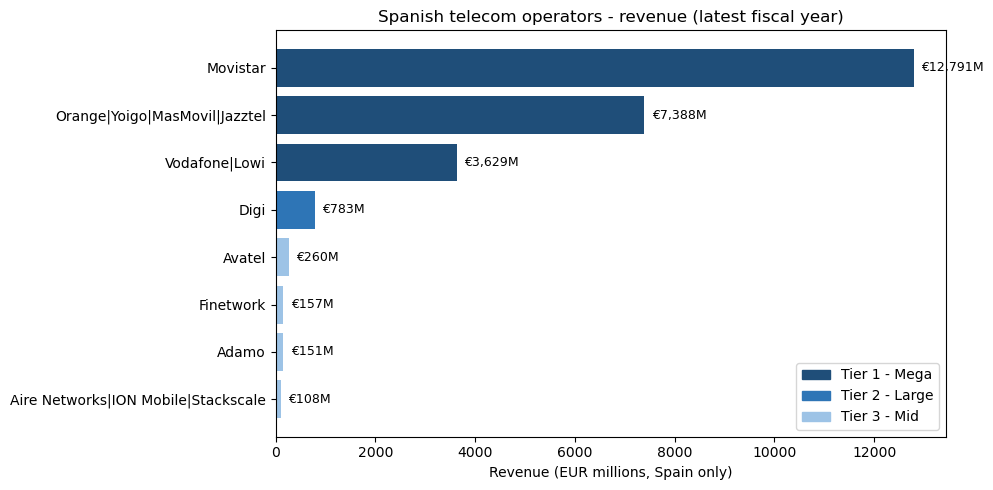

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = operators.dropna(subset=['revenue_eur']).sort_values('revenue_eur', ascending=True)

# Color by tier
tier_colors = {'Tier 1 - Mega': '#1f4e79', 'Tier 2 - Large': '#2e75b6', 'Tier 3 - Mid': '#9dc3e6'}
colors = plot_df['size_tier'].map(tier_colors).fillna('#cccccc')

ax.barh(plot_df['trade_name'], plot_df['revenue_eur'] / 1e6, color=colors)
ax.set_xlabel('Revenue (EUR millions, Spain only)')
ax.set_title('Spanish telecom operators - revenue (latest fiscal year)')

for i, v in enumerate(plot_df['revenue_eur'] / 1e6):
    ax.text(v + 150, i, f'€{v:,.0f}M', va='center', fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=t) for t, c in tier_colors.items()]
ax.legend(handles=legend_handles, loc='lower right')

plt.tight_layout()
plt.show()

## 5. Chart: mobile lines per operator (MNOs + MVNOs)

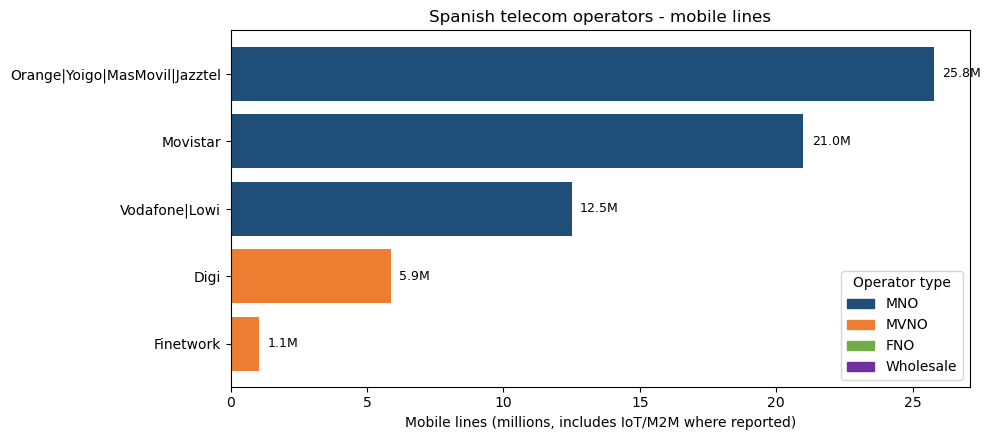

In [21]:
fig, ax = plt.subplots(figsize=(10, 4.5))
plot_df = operators.dropna(subset=['mobile_lines_total']).sort_values('mobile_lines_total', ascending=True)

# Color by operator_type
type_colors = {'MNO': '#1f4e79', 'MVNO': '#ed7d31', 'FNO': '#70ad47', 'Wholesale': '#7030a0'}
colors = plot_df['operator_type'].map(type_colors).fillna('#cccccc')

ax.barh(plot_df['trade_name'], plot_df['mobile_lines_total'] / 1e6, color=colors)
ax.set_xlabel('Mobile lines (millions, includes IoT/M2M where reported)')
ax.set_title('Spanish telecom operators - mobile lines')

for i, v in enumerate(plot_df['mobile_lines_total'] / 1e6):
    ax.text(v + 0.3, i, f'{v:.1f}M', va='center', fontsize=9)

# Legend
legend_handles = [Patch(color=c, label=t) for t, c in type_colors.items()]
ax.legend(handles=legend_handles, loc='lower right', title='Operator type')

plt.tight_layout()
plt.show()

## 6. Chart: FTTH premises passed (network footprint)

`ftth_premises_passed` measures the unique homes the operator's fiber reaches. Sum across operators exceeds Spain's housing stock because of overbuild (multiple operators serving the same home).

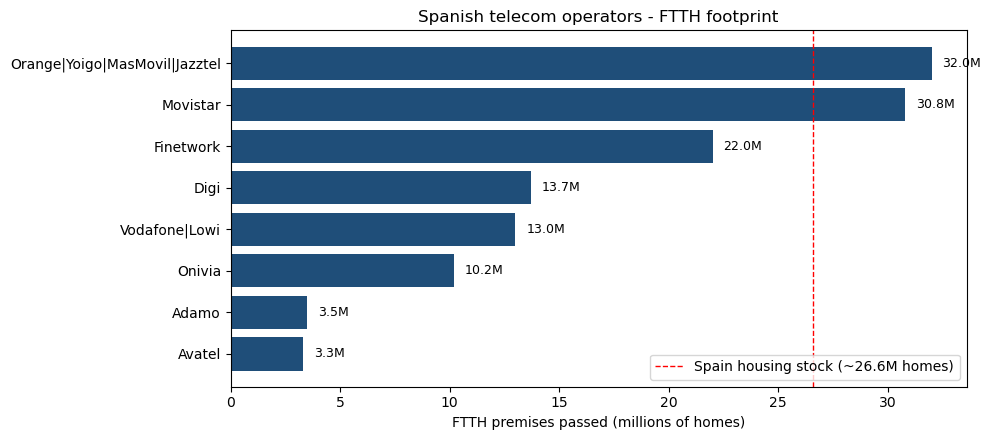

Sum of FTTH premises passed: 128.5M
Spain housing stock (INE 2024): 26.6M
Average overbuild factor: 4.83x


In [24]:
fig, ax = plt.subplots(figsize=(10, 4.5))
plot_df = operators.dropna(subset=['ftth_premises_passed']).sort_values('ftth_premises_passed', ascending=True)

ax.barh(plot_df['trade_name'], plot_df['ftth_premises_passed'] / 1e6, color='#1f4e79')
ax.set_xlabel('FTTH premises passed (millions of homes)')
ax.set_title('Spanish telecom operators - FTTH footprint')

for i, v in enumerate(plot_df['ftth_premises_passed'] / 1e6):
    ax.text(v + 0.5, i, f'{v:.1f}M', va='center', fontsize=9)

# Spain housing stock reference line
spain_homes = 26.6  # ~26.6M households per INE 2024
ax.axvline(spain_homes, color='red', linestyle='--', linewidth=1, label=f'Spain housing stock (~{spain_homes:.1f}M homes)')
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

print(f'Sum of FTTH premises passed: {plot_df["ftth_premises_passed"].sum() / 1e6:.1f}M')
print(f'Spain housing stock (INE 2024): {spain_homes:.1f}M')
print(f'Average overbuild factor: {plot_df["ftth_premises_passed"].sum() / 1e6 / spain_homes:.2f}x')

## 7. Chart: capex per operator (disclosed only)

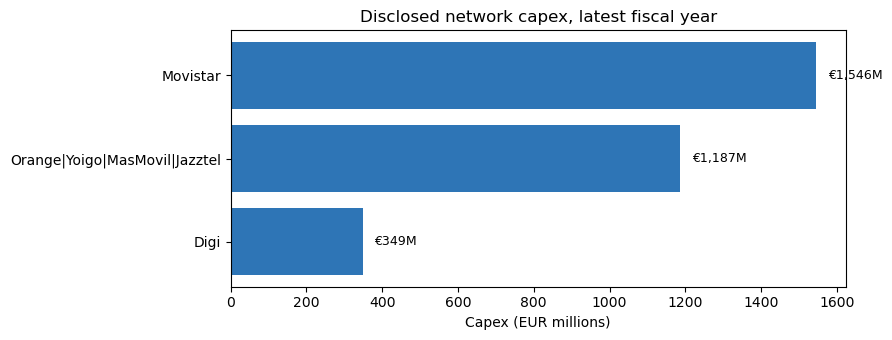

Operators disclosing capex: 3/9
Total disclosed capex: €3,082M


In [27]:
capex_df = operators.dropna(subset=['capex_eur']).sort_values('capex_eur', ascending=True)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.barh(capex_df['trade_name'], capex_df['capex_eur'] / 1e6, color='#2e75b6')
ax.set_xlabel('Capex (EUR millions)')
ax.set_title('Disclosed network capex, latest fiscal year')

for i, v in enumerate(capex_df['capex_eur'] / 1e6):
    ax.text(v + 30, i, f'€{v:,.0f}M', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f'Operators disclosing capex: {len(capex_df)}/{len(operators)}')
print(f'Total disclosed capex: €{capex_df["capex_eur"].sum() / 1e6:,.0f}M')

## 8. Margin & efficiency analysis

Two views of operator efficiency:
1. **EBITDA margin** — profitability (6 operators with disclosure).
2. **CapEx intensity** — investment phase (3 operators with both CapEx and Revenue disclosed).

Joint analysis (scatter EBITDA vs CapEx) is not viable: only Telefónica and MasOrange disclose both metrics for Spain. Vodafone, Digi, and Onivia don't break out one or both at the Spanish-entity level.

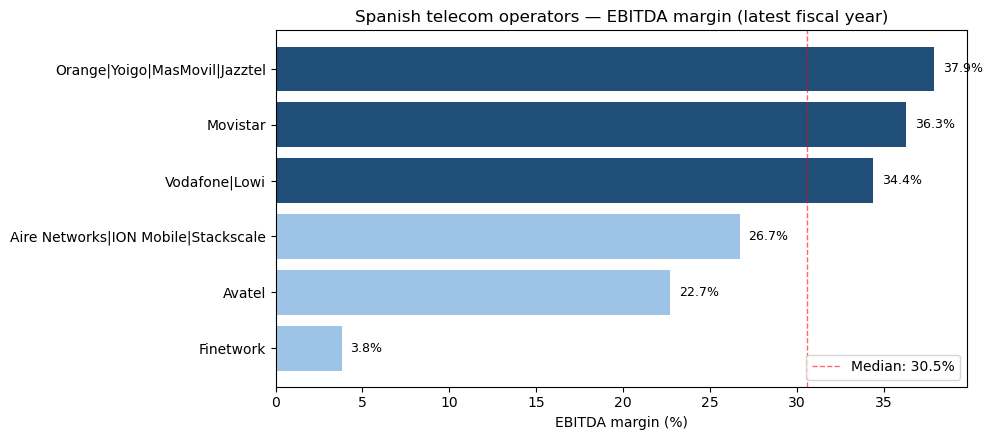

Operators with EBITDA margin disclosed: 6/9
Spread: 3.8% (Finetwork) - 37.9% (MasOrange)

CapEx intensity (CapEx / Revenue):
                   trade_name    capex_eur  revenue_eur  capex_intensity_calc      size_tier market_role
                         Digi  349000000.0 7.830000e+08             44.572158 Tier 2 - Large   Disruptor
Orange|Yoigo|MasMovil|Jazztel 1187000000.0 7.388000e+09             16.066594  Tier 1 - Mega  Challenger
                     Movistar 1546000000.0 1.279100e+10             12.086623  Tier 1 - Mega   Incumbent

Insight: Digi at 44.6% reflects greenfield infrastructure investment (own mobile network + FTTH).
Telefonica at 12.1% and MasOrange at 16.1% reflect mature operators in maintenance phase.


In [48]:
# === EBITDA MARGIN COMPARISON (6 operators) ===
margin_df = operators.dropna(subset=['ebitda_margin_pct']).sort_values('ebitda_margin_pct', ascending=True)

fig, ax = plt.subplots(figsize=(10, 4.5))

# Color by tier
tier_colors = {'Tier 1 - Mega': '#1f4e79', 'Tier 2 - Large': '#2e75b6', 'Tier 3 - Mid': '#9dc3e6'}
colors = margin_df['size_tier'].map(tier_colors).fillna('#cccccc')

ax.barh(margin_df['trade_name'], margin_df['ebitda_margin_pct'], color=colors)
ax.set_xlabel('EBITDA margin (%)')
ax.set_title('Spanish telecom operators — EBITDA margin (latest fiscal year)')

# Reference line: median
median_margin = margin_df['ebitda_margin_pct'].median()
ax.axvline(median_margin, color='red', linestyle='--', linewidth=1, alpha=0.6, label=f'Median: {median_margin:.1f}%')
ax.legend(loc='lower right')

for i, v in enumerate(margin_df['ebitda_margin_pct']):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f'Operators with EBITDA margin disclosed: {len(margin_df)}/{len(operators)}')
print(f'Spread: {margin_df["ebitda_margin_pct"].min():.1f}% (Finetwork) - {margin_df["ebitda_margin_pct"].max():.1f}% (MasOrange)')
print()

# === CAPEX INTENSITY ANALYSIS (3 operators with both fields) ===
capex_int_df = operators.copy()
capex_int_df['capex_intensity_calc'] = (capex_int_df['capex_eur'] / capex_int_df['revenue_eur']) * 100
capex_int_df = capex_int_df.dropna(subset=['capex_intensity_calc'])
capex_int_df = capex_int_df[['trade_name', 'capex_eur', 'revenue_eur', 'capex_intensity_calc', 'size_tier', 'market_role']]
capex_int_df = capex_int_df.sort_values('capex_intensity_calc', ascending=False)

print('CapEx intensity (CapEx / Revenue):')
print(capex_int_df.to_string(index=False))
print()
print('Insight: Digi at 44.6% reflects greenfield infrastructure investment (own mobile network + FTTH).')
print('Telefonica at 12.1% and MasOrange at 16.1% reflect mature operators in maintenance phase.')

In [50]:
# Formatted version for presentation
display_df = capex_int_df.copy()
display_df['capex_eur'] = display_df['capex_eur'].apply(lambda x: f'€{x/1e6:,.0f}M')
display_df['revenue_eur'] = display_df['revenue_eur'].apply(lambda x: f'€{x/1e6:,.0f}M')
display_df['capex_intensity_calc'] = display_df['capex_intensity_calc'].apply(lambda x: f'{x:.1f}%')
display_df.columns = ['Operator', 'CapEx', 'Revenue', 'CapEx intensity', 'Size tier', 'Market role']
print(display_df.to_string(index=False))

                     Operator   CapEx  Revenue CapEx intensity      Size tier Market role
                         Digi   €349M    €783M           44.6% Tier 2 - Large   Disruptor
Orange|Yoigo|MasMovil|Jazztel €1,187M  €7,388M           16.1%  Tier 1 - Mega  Challenger
                     Movistar €1,546M €12,791M           12.1%  Tier 1 - Mega   Incumbent


## 9. Operator typology breakdown

Cross-tabulation of `operator_type` vs `market_role` to see how the 9 operators distribute across the strategic-archetype matrix.

In [33]:
typology = pd.crosstab(operators['operator_type'], operators['market_role'], margins=True, margins_name='Total')
print('Operator type x Market role:')
print(typology)
print()

# Listing
print('Detailed listing:')
typology_detail = operators[['trade_name', 'operator_type', 'market_role', 'size_tier', 'wholesale_only']].sort_values(['operator_type', 'market_role'])
typology_detail

Operator type x Market role:
market_role    Challenger  Disruptor  Incumbent  Niche  Total
operator_type                                                
FNO                     0          0          0      3      3
MNO                     2          0          1      0      3
MVNO                    0          1          0      1      2
Wholesale               0          0          0      1      1
Total                   2          1          1      5      9

Detailed listing:


,trade_name,operator_type,market_role,size_tier,wholesale_only
5,Avatel,FNO,Niche,Tier 3 - Mid,False
6,Adamo,FNO,Niche,Tier 3 - Mid,False
7,Onivia,FNO,Niche,Tier 2 - Large,True
1,Orange|Yoigo|MasMovil|Jazztel,MNO,Challenger,Tier 1 - Mega,False
2,Vodafone|Lowi,MNO,Challenger,Tier 1 - Mega,False
0,Movistar,MNO,Incumbent,Tier 1 - Mega,False
3,Digi,MVNO,Disruptor,Tier 2 - Large,False
4,Finetwork,MVNO,Niche,Tier 3 - Mid,False
8,Aire Networks|ION Mobile|Stackscale,Wholesale,Niche,Tier 3 - Mid,False


## 10. M&A activity heat-map

Spanish telecom went through a major reshape in 2024. This view aggregates which operators had M&A or major restructuring events in the last 24 months. Useful for sponsor relevance — operators in transition often need consulting/integration work.

In [36]:
# Anyone with a non-empty ma_status_24m field has had recent activity
ma_active = operators[operators['ma_status_24m'].notna()].copy()

print(f'Operators with M&A / restructuring activity in last 24 months: {len(ma_active)}/{len(operators)}')
print()

# Compact display
for _, row in ma_active.iterrows():
    print(f"-- {row['trade_name']} ({row['size_tier']})")
    # Wrap the long ma_status_24m text
    text = row['ma_status_24m']
    # Print first 200 chars
    print(f"   {text[:200]}{'...' if len(text) > 200 else ''}")
    print()

Operators with M&A / restructuring activity in last 24 months: 9/9

-- Movistar (Tier 1 - Mega)
   SEPI 10% stake (2023-2024); Marc Murtra new Executive Chairman (Jan 2025); copper network shutdown 90% completed 2024

-- Orange|Yoigo|MasMovil|Jazztel (Tier 1 - Mega)
   Created via 50:50 JV merger Orange Espana + MasMovil (Mar-2024); 60 MHz spectrum divestiture to DIGI; Vodafone Spain FiberCo non-binding agreement (Jul-2024); IPO planned for 2025-2026

-- Vodafone|Lowi (Tier 1 - Mega)
   Acquired by Zegona from Vodafone Group 5bn EUR (May 2024); ERE 1198 employees (Jun 2024); FiberCo JV with MasOrange; FiberCo JV negotiation with Telefonica; Finetwork OMV agreement migrating 1.2M line...

-- Digi (Tier 2 - Large)
   Beneficiary of MasOrange merger remedies (60 MHz spectrum acquisition); 6M FTTH homes sold to Onivia (2024) with usage rights retained; National roaming agreement with Telefonica; Own mobile network c...

-- Finetwork (Tier 3 - Mid)
   Transformation from reseller to full-MV

## 11. Data quality summary

In [39]:
# Confidence distribution at field level (sources)
conf_summary = sources.groupby('confidence').size().rename('citations').to_frame()
conf_summary['share'] = (conf_summary['citations'] / conf_summary['citations'].sum() * 100).round(1)
print('Citation confidence distribution (sources.csv):')
print(conf_summary)
print()

# Source type distribution
src_type_summary = sources.groupby('source_type').size().rename('citations').to_frame()
src_type_summary['share'] = (src_type_summary['citations'] / src_type_summary['citations'].sum() * 100).round(1)
src_type_summary = src_type_summary.sort_values('citations', ascending=False)
print('Source type distribution:')
print(src_type_summary)
print()

# Confidence at operator level (overall flag)
print('Operators by overall confidence (operators.csv):')
print(operators['confidence_overall'].value_counts())
print()

# NaN map
missing_by_field = operators.isna().sum().sort_values(ascending=False)
missing_by_field = missing_by_field[missing_by_field > 0]
print(f'Columns with NA values ({len(missing_by_field)} of {operators.shape[1]} columns):')
print(missing_by_field)
print()

# Citations per operator
print('Citations per operator:')
print(sources.groupby('operator_id').size().sort_values(ascending=False))

Citation confidence distribution (sources.csv):
            citations  share
confidence                  
High              100   71.4
Low                 2    1.4
Medium             38   27.1

Source type distribution:
                       citations  share
source_type                            
press                         61   43.6
company_website               30   21.4
mercantile_registry           21   15.0
company_annual_report         12    8.6
industry_association          11    7.9
analyst                        4    2.9
regulator                      1    0.7

Operators by overall confidence (operators.csv):
confidence_overall
Medium    5
High      4
Name: count, dtype: int64

Columns with NA values (20 of 42 columns):
lei                         9
duns_number                 9
towers_or_sites             8
arpu_convergent_eur         8
network_km_total            7
pay_tv_customers            7
capex_intensity_pct         6
capex_eur                   6
coverage_5g_pop_p

## 12. Open items for next refresh

**Data gaps to close:**
- Confirm Onivia legal name and CIF from BORME (currently blank — private company opacity).
- Obtain audited FY2024 financials for Avatel (currently FY2023) once accounts are deposited.
- Obtain audited FY2024 financials for Aire Networks once accounts are deposited.
- Vodafone España CapEx — Zegona reports EBITDA-CapEx quarterly but not the consolidated CapEx figure.
- Telefónica España exact post-ERE 2024 employee count — currently estimated from Statista 2023 baseline minus ERE.

**Tracking developments (post-2024 events to incorporate in next refresh):**
- Finetwork: Vodafone took control via debt capitalization in September 2025 — reclassify as Vodafone subsidiary.
- Adamo: Project Sunrise spinoff (Adamo Conecta SL) registered in 2026 — capture new entity once active.
- Digi: own mobile network commercial launch (1-July-2025) → reclassify `operator_type` from MVNO to MNO.
- MasOrange: planned IPO 2025-2026 — capture listing data when available.
- Avatel: ongoing sale process — capture new ownership when closed.

**Schema improvements for next iteration:**
- Add `network_dependencies` column listing operators whose infrastructure each operator relies on (for graph analysis).
- Add `b2b_revenue_share_pct` once operators improve B2B disclosure (currently parent-group only).
- Split `mobile_lines_total` into postpaid / prepaid / IoT subtypes when operators disclose.
- Extend the same schema to other Spain verticals (water, gas, transit) following the cross-vertical methodology.

## 13. Executive summary — key takeaways

**Market structure:**
- Spanish telecom retail market: ~36 B€ in 2024 (CNMC)
- HHI = 1,788 → moderately concentrated, not a monopoly. Top 3 operators control 66% of revenue.
- Big-4 reshape in 2024: 9/9 operators in our dataset had M&A activity (mergers, acquisitions, restructurings, ownership changes).

**Infrastructure footprint:**
- FTTH overbuild factor: 4.83x (128.5M premises passed for 26.6M homes). Spain is the most overbuilt fiber market in Europe.
- 5G deployment near complete: 82-91% population coverage across the Top 3 MNOs.
- Critical infrastructure consolidation underway: copper network shutdown (Telefónica 90% complete), tower divestments (Telxius, Vantage), FiberCo JV formation.

**Hexagon/Octave product fit signals:**
- Highest CapEx intensity: Digi 44.6% (greenfield infrastructure phase) — prime EAM/GIS target.
- Lowest churn: Telefónica 0.99% (vs Vodafone 0.84%, MasOrange 0.80%) — quality-driven incumbent.
- Wholesale infrastructure operators (Onivia 10.2M premises, Adamo 3.5M, Avatel 3.3M) operate complex multi-stakeholder networks → fit for ETQ/quality and GIS.

**Data quality:**
- Citation confidence: 71.4% High, 27.1% Medium, 1.4% Low.
- 4 operators with confidence_overall = High; 5 with Medium (mostly private companies and FY2023-only data).
- Source diversity: 7 source types, with primary press 43.6% and corporate websites 21.4%.

---

*Notebook last refreshed: 2026-04-30 — see `data_collection_date` in `operators.csv` for per-row update tracking.*
*Methodology reference: `../docs/methodology_telecom.md`*
*Schema reference: `../docs/data_dictionary_telecom.md`*